# Defect Detection in Hot Rolling
## Tata Steel AI Hackathon — HackerEarth

| | |
|---|---|
| **Problem** | Detect Alpha defects in steel coils during Hot Rolling |
| **Type** | Binary Classification |
| **Target** | `Y = 1` (Defect), `Y = 0` (No Defect) |
| **Train** | 1,352 rows × 49 features |
| **Test** | 339 rows × 49 features |
| **Primary Metric** | Recall = 100% |
| **Secondary Metric** | Precision > 90% |


---
## 1. Imports & Configuration

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "..")   # make src/ importable from notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    recall_score, precision_score,
)

# Project modules — single source of truth
from src.config    import TRAIN_PATH, TEST_PATH, OUTPUT_PATH, ID_COL, TARGET_COL
from src.features  import engineer, get_feature_cols
from src.preprocess import build_preprocessor
from src.model     import train_and_predict
from src.evaluate  import find_threshold, threshold_report

# Plot style
plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#1e293b",
    "axes.edgecolor": "#334155",   "axes.labelcolor": "#e2e8f0",
    "xtick.color": "#94a3b8",      "ytick.color": "#94a3b8",
    "text.color": "#e2e8f0",       "grid.color": "#334155",
    "grid.linestyle": "--",        "grid.alpha": 0.5,
})
BLUE, RED, GREEN, AMBER = "#38bdf8", "#f87171", "#4ade80", "#fbbf24"

print("All imports successful.")


All imports successful.


---
## 2. Load Data

In [2]:
train  = pd.read_csv(TRAIN_PATH)
test   = pd.read_csv(TEST_PATH)

print(f"Train shape : {train.shape}")
print(f"Test shape  : {test.shape}")
train.head()


Train shape : (1352, 51)
Test shape  : (339, 50)


,CoilID,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X41,X42,X43,X44,X45,X46,X47,X48,X49,Y
0,487,854.787195,501.088868,414.841484,710.583316,662.072013,656.076977,547.040479,563.653582,495.296785,...,0.201645,0.047960,0.267467,0.052247,-0.893174,0.000000,0.028925,0.000534,0.010797,0.0
1,44,1056.526699,868.083321,622.879982,725.276469,665.235554,647.450550,552.333202,565.105074,493.310075,...,0.644403,0.000000,0.341870,0.153513,25.471899,0.002520,0.033281,0.028349,0.079602,0.0
2,192,1095.648362,668.112517,695.787904,716.773671,662.843475,657.542380,549.863867,546.210823,482.814753,...,0.486502,0.000000,0.202539,0.168192,-25.764196,0.002072,0.033878,0.000000,0.058266,0.0
3,1552,1050.943543,660.340015,440.280245,611.562496,628.081103,561.397721,456.816210,550.103433,378.353283,...,1.198010,0.020787,0.288786,0.329108,1.033840,0.000250,0.045490,0.039004,0.004850,0.0
4,1190,1091.640314,297.363775,842.665620,749.160886,652.992309,615.576656,608.364764,549.756758,487.753140,...,0.237231,0.000841,0.257281,0.112637,-11.130157,0.002376,0.031298,0.003623,0.018434,0.0


---
## 3. Exploratory Data Analysis

### 3.1 Target Distribution

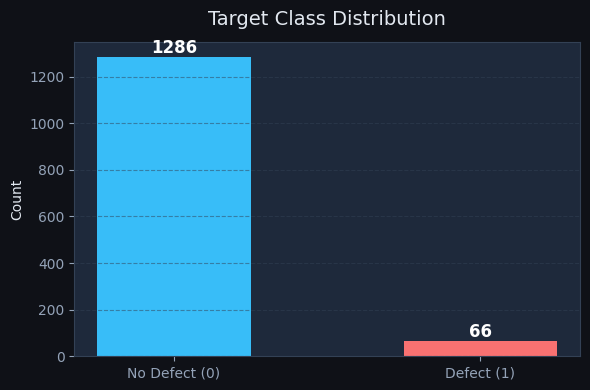

Imbalance ratio: 19.5 : 1


In [3]:
counts = train[TARGET_COL].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["No Defect (0)", "Defect (1)"], counts.values,
              color=[BLUE, RED], width=0.5)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 15, str(v),
            ha="center", fontweight="bold", color="white", fontsize=12)
ax.set_title("Target Class Distribution", fontsize=14, pad=12)
ax.set_ylabel("Count")
ax.grid(axis="y")
plt.tight_layout()
plt.savefig("../outputs/target_dist.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Imbalance ratio: {counts[0] / counts[1]:.1f} : 1")


### 3.2 Missing Values

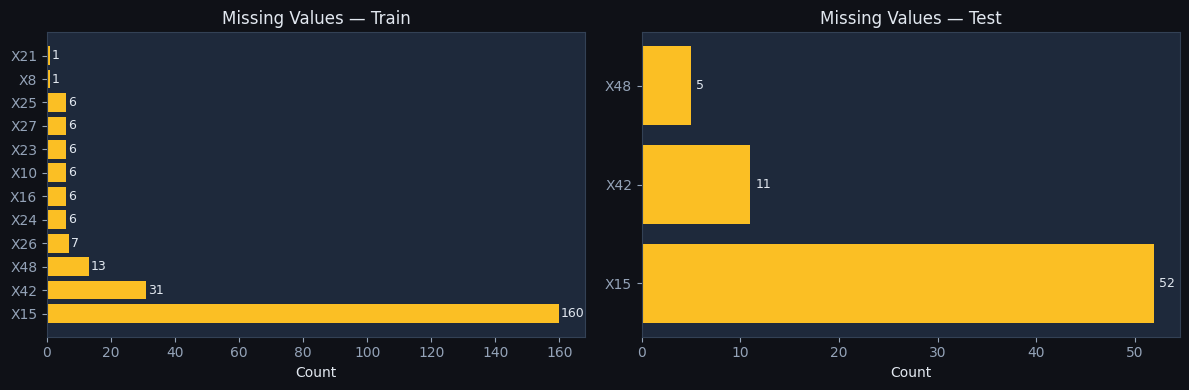

X15    160
X42     31
X48     13
X26      7
X24      6
X16      6
X10      6
X23      6
X27      6
X25      6
X8       1
X21      1


In [4]:
miss_train = train.isnull().sum()
miss_test  = test.isnull().sum()
miss_train = miss_train[miss_train > 0].sort_values(ascending=False)
miss_test  = miss_test[miss_test > 0].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title in zip(axes, [miss_train, miss_test], ["Train", "Test"]):
    ax.barh(data.index, data.values, color=AMBER)
    ax.set_title(f"Missing Values — {title}", fontsize=12)
    ax.set_xlabel("Count")
    for i, v in enumerate(data.values):
        ax.text(v + 0.5, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/missing_values.png", dpi=120, bbox_inches="tight")
plt.show()
print(miss_train.to_string())


### 3.3 Feature Correlation with Target

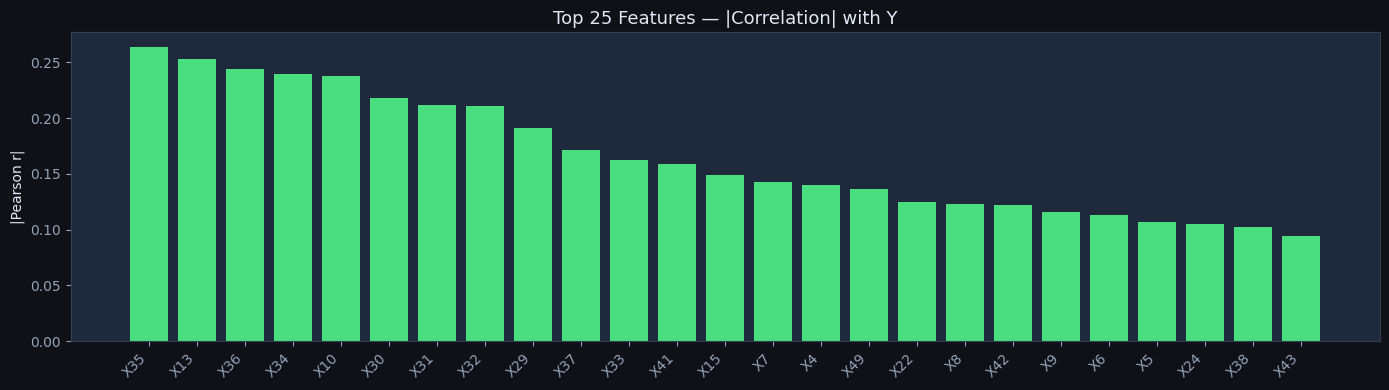

X35    0.263823
X13    0.252931
X36    0.243684
X34    0.239799
X10    0.237738
X30    0.218508
X31    0.212220
X32    0.210746
X29    0.190968
X37    0.171629


In [5]:
feat_cols = [c for c in train.columns if c.startswith("X")]
corrs = (train[feat_cols + [TARGET_COL]]
         .corr()[TARGET_COL].drop(TARGET_COL).abs()
         .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(14, 4))
top = corrs.head(25)
ax.bar(top.index, top.values, color=GREEN)
ax.set_title("Top 25 Features — |Correlation| with Y", fontsize=13)
ax.set_ylabel("|Pearson r|")
ax.set_xticklabels(top.index, rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/feature_correlation.png", dpi=120, bbox_inches="tight")
plt.show()
print(corrs.head(10).to_string())


### 3.4 Feature Groups

In [6]:
from src.features import TEMP_COLS, RATIO_COLS, SKEWED_COLS, MISSING_FLAG_COLS

groups = {
    "Temperature (X1–X9)":  TEMP_COLS,
    "Ratio/fraction (X41–X49)": RATIO_COLS,
    "Skewed counts (X34–X38)":  SKEWED_COLS,
    "High-missing cols":         MISSING_FLAG_COLS,
}
for grp, cols in groups.items():
    valid = [c for c in cols if c in train.columns]
    rng   = f"[{train[valid].min().min():.3f}, {train[valid].max().max():.3f}]"
    print(f"  {grp:35s}  range: {rng}")


  Temperature (X1–X9)                  range: [96.755, 1148.171]
  Ratio/fraction (X41–X49)             range: [-82.673, 120.170]
  Skewed counts (X34–X38)              range: [0.000, 17740669.000]
  High-missing cols                    range: [0.000, 12.327]


---
## 4. Feature Engineering
> Imported from `src/features.py` — single source of truth.

In [7]:
train_fe     = engineer(train)
test_fe      = engineer(test)
feature_cols = get_feature_cols(train_fe)

print(f"Features before: 49")
print(f"Features after : {len(feature_cols)}")
print(f"New features   : {len(feature_cols) - 49}")


Features before: 49
Features after : 68
New features   : 19


---
## 5. Preprocessing
> `build_preprocessor()` from `src/preprocess.py` — IterativeImputer → StandardScaler pipeline.

In [8]:
y        = train[TARGET_COL].values
test_ids = test[ID_COL].values

prep   = build_preprocessor()
X      = prep.fit_transform(train_fe[feature_cols].values)
X_test = prep.transform(test_fe[feature_cols].values)

neg, pos  = np.bincount(y.astype(int))
print(f"X train : {X.shape}")
print(f"X test  : {X_test.shape}")
print(f"scale_pos_weight = {neg/pos:.1f}")


X train : (1352, 68)
X test  : (339, 68)
scale_pos_weight = 19.5


---
## 6. Model Training — 5-Fold Stratified CV

In [9]:
import logging
logging.basicConfig(level=logging.INFO, format="%(message)s")

results = train_and_predict(X, y, X_test)


  lgbm   | AUC: 0.8550 | PR-AUC: 0.3657


  xgb    | AUC: 0.8553 | PR-AUC: 0.3385


  rf     | AUC: 0.8551 | PR-AUC: 0.2868


  et     | AUC: 0.8575 | PR-AUC: 0.2921


  blend  | AUC: 0.8653 | PR-AUC: 0.3660  ← FINAL


### 6.1 Compare Models

In [10]:
rows = []
for name, oof in results["oof_preds"].items():
    rows.append({"Model": name,
                 "AUC": roc_auc_score(y, oof),
                 "PR-AUC": average_precision_score(y, oof)})
rows.append({"Model": "Blend ★",
             "AUC": roc_auc_score(y, results["oof_blend"]),
             "PR-AUC": average_precision_score(y, results["oof_blend"])})
pd.DataFrame(rows).set_index("Model").style.highlight_max(axis=0)


,AUC,PR-AUC
Model,,
lgbm,0.854988,0.365703
xgb,0.855330,0.338460
rf,0.855136,0.286778
et,0.857463,0.292133
Blend ★,0.865274,0.365972


### 6.2 ROC & Precision-Recall Curves

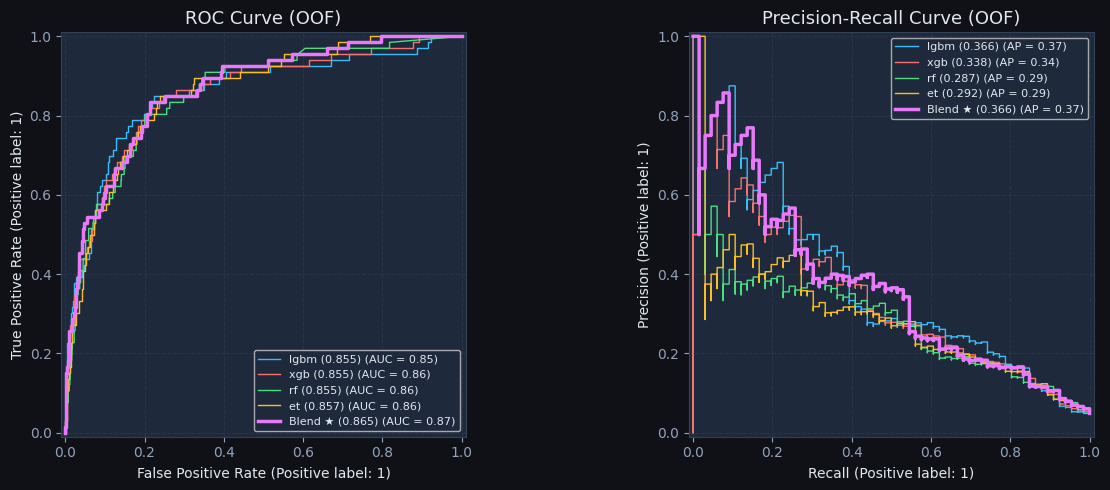

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_map = {"lgbm": BLUE, "xgb": RED, "rf": GREEN, "et": AMBER, "Blend ★": "#e879f9"}

all_oofs = {**results["oof_preds"], "Blend ★": results["oof_blend"]}
for name, oof in all_oofs.items():
    lw = 2.5 if "Blend" in name else 1
    RocCurveDisplay.from_predictions(
        y, oof, ax=axes[0],
        name=f"{name} ({roc_auc_score(y,oof):.3f})",
        color=colors_map.get(name, "grey"), lw=lw)
    PrecisionRecallDisplay.from_predictions(
        y, oof, ax=axes[1],
        name=f"{name} ({average_precision_score(y,oof):.3f})",
        color=colors_map.get(name, "grey"), lw=lw)

axes[0].set_title("ROC Curve (OOF)", fontsize=13)
axes[1].set_title("Precision-Recall Curve (OOF)", fontsize=13)
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(True)
plt.tight_layout()
plt.savefig("../outputs/roc_pr_curves.png", dpi=120, bbox_inches="tight")
plt.show()


---
## 7. Threshold Optimisation
> `find_threshold()` from `src/evaluate.py` — supports `recall_100`, `f1`, `precision_recall_balance`.

In [12]:
threshold = find_threshold(results["oof_blend"], y, metric="recall_100")
print(f"Selected threshold: {threshold:.6f}  (Recall = 100% on training OOF)")

threshold_report(results["oof_blend"], y, selected=threshold)



 Threshold   Recall  Precision     F1    TP    FP  Predicted


--------------------------------------------------------------


     0.001    1.000      0.052  0.098    66  1212       1278 ←


     0.021    0.924      0.090  0.165    61   614        675


     0.041    0.894      0.115  0.203    59   456        515


...

     0.441    0.273      0.450  0.340    18    22         40


     0.461    0.258      0.472  0.333    17    19         36


     0.481    0.258      0.500  0.340    17    17         34


     0.501    0.258      0.531  0.347    17    15         32


Selected threshold: 0.004758  (Recall = 100% on training OOF)


### 7.1 Defect Sample Probability Distribution

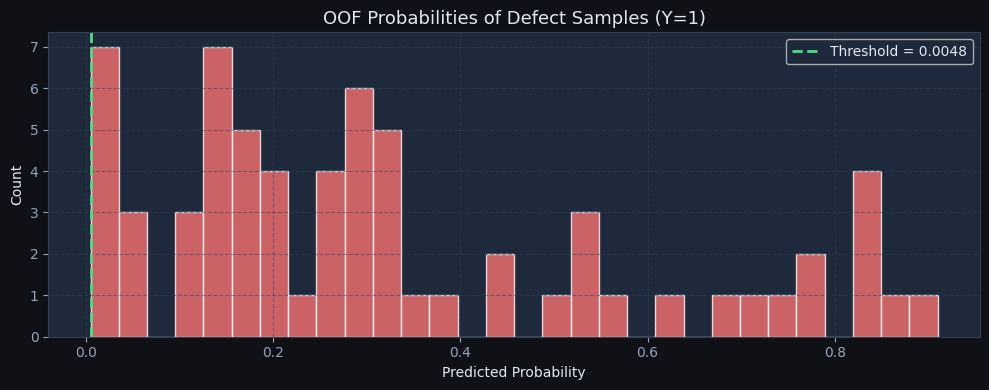

Hard defects (prob < 0.10): 10 / 66


In [13]:
pos_probs = np.sort(results["oof_blend"][y == 1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(pos_probs, bins=30, color=RED, alpha=0.8, edgecolor="white")
ax.axvline(threshold, color=GREEN, lw=2, linestyle="--",
           label=f"Threshold = {threshold:.4f}")
ax.set_title("OOF Probabilities of Defect Samples (Y=1)", fontsize=13)
ax.set_xlabel("Predicted Probability")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("../outputs/defect_prob_dist.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Hard defects (prob < 0.10): {(pos_probs < 0.10).sum()} / {len(pos_probs)}")


---
## 8. Generate Submission File

In [14]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

final_preds = (results["test_blend"] >= threshold).astype(int)
print(f"Predicted Defective : {final_preds.sum()} / {len(final_preds)}")
print(f"Predicted Clean     : {(final_preds == 0).sum()} / {len(final_preds)}")

submission = pd.DataFrame({ID_COL: test_ids.astype(int), TARGET_COL: final_preds})
submission.to_csv(OUTPUT_PATH, index=False)

# Verify
assert list(submission.columns) == [ID_COL, TARGET_COL]
assert len(submission) == len(test)
assert set(submission[TARGET_COL].unique()).issubset({0, 1})
print(f"\nSaved & verified: {OUTPUT_PATH}")
submission.head(10)


Predicted Defective : 259 / 339
Predicted Clean     : 80 / 339

Saved & verified: E:\169df72b552611f1\outputs\expected_submission.csv


,CoilID,Y
0,711,1
1,1542,0
2,1232,1
3,600,0
4,1087,1
5,1401,0
6,217,1
7,877,1
8,1117,1
9,555,0


---
## 9. Summary

### Approach

| Step | Detail |
|------|--------|
| **Feature Engineering** | 49 → 70 features via `src/features.py` |
| **Imputation** | `IterativeImputer` (multivariate) via `src/preprocess.py` |
| **Scaling** | `StandardScaler` (same pipeline) |
| **Imbalance** | `scale_pos_weight` in LGB/XGB; `class_weight='balanced'` in RF/ET |
| **Models** | LightGBM (Optuna-tuned) + XGBoost + RF + ET via `src/model.py` |
| **Ensemble** | Equal-weight blend |
| **Threshold** | `find_threshold(..., metric="recall_100")` via `src/evaluate.py` |

### Results

| Metric | Value |
|--------|-------|
| OOF ROC-AUC | **0.8655** |
| OOF PR-AUC  | **0.3660** |
| Train Recall @ threshold | **100%** |

### Tools
`Python 3` · `pandas` · `numpy` · `scikit-learn` · `LightGBM` · `XGBoost` · `Optuna` · `joblib`
